# ISIC 2024 - LightGBM on the Metadata

Goal: beat the logistic regression benchmark (pAUC 0.1116 +/- 0.0205) on the same 5 patient folds.

I build the model up in steps so every change can be compared:
1. **v1** - LightGBM on the raw metadata (numeric + categorical)
2. **v2** - v1 + engineered features
3. **v3** - v2 + patient-normalized features ("ugly duckling")
4. Comparison, feature importance and saving the out-of-fold predictions for blending with the CNN later

In [63]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

sys.path.insert(0, '../src')
from isic_pauc import p_auc_tpr

DATA_DIR = '../data'
SEED = 42
N_FOLDS = 5

## 1. Load data, drop leaks, add the saved folds
Using the folds from `folds.csv` so the results can be compared with the benchmarks.

In [64]:
train = pd.read_csv(f'{DATA_DIR}/train-metadata.csv', low_memory=False)
test = pd.read_csv(f'{DATA_DIR}/test-metadata.csv')
folds = pd.read_csv(f'{DATA_DIR}/folds.csv')

leak_cols = [col for col in train.columns if col not in test.columns and col != 'target']
train = train.drop(columns=leak_cols)

train = train.merge(folds[['isic_id', 'fold']], on='isic_id', how='left')

assert train['fold'].notna().all()
train.shape

(401059, 46)

## 2. Features v1: raw metadata
- Numeric: every numeric column except `target` and `fold`.
- Categorical: `anatom_site_general`, `sex`, `tbp_tile_type`, `tbp_lv_location` as `category` dtype, LightGBM can use them directly.
- Not used: `isic_id` and `patient_id` (ids, nothing to learn from them), `image_type` (same value everywhere), `attribution` and `copyright_license` (the hospital / license of the photo, not something about the lesion itself).

In [65]:
num_cols = train.select_dtypes('number').drop(columns=['target', 'fold']).columns.tolist()

cat_cols = ['anatom_site_general', 'sex', 'tbp_tile_type', 'tbp_lv_location']

for col in cat_cols:
    train[col] = train[col].astype('category')

features_v1 = num_cols + cat_cols
print(len(features_v1))

38


## 3. Cross-validation function
Same function for every version, only the feature list changes. It trains on 4 folds and predicts the 5th. I don't use early stopping on the validation fold because that would make the score look better than it really is.

In [120]:
BASE_PARAMS = {
    'objective': 'binary',
    'learning_rate': 0.05,
    'n_estimators': 300,
    'num_leaves': 31,
    'min_child_samples': 20,
    'subsample': 0.8,
    'subsample_freq': 1,
    'colsample_bytree': 0.8,
    'random_state': SEED,
    'verbose': -1,
}


def run_cv(df, features, params=BASE_PARAMS, name='model'):
    oof = np.zeros(len(df))
    paucs, aucs = [], []
    models = []

    for fold in range(N_FOLDS):
        trn = df[df['fold'] != fold]
        val = df[df['fold'] == fold]

        model = lgb.LGBMClassifier(**params)

        model.fit(trn[features], trn['target'])

        pred = model.predict_proba(val[features])[:, 1]
        oof[(df['fold'] == fold).to_numpy()] = pred

        pauc = p_auc_tpr(val['target'], pred, 0.80)
        auc = roc_auc_score(val['target'], pred)

        paucs.append(pauc)
        aucs.append(auc)
        models.append(model)
        print(f'{name} fold {fold}: pAUC={pauc:.4f}  AUC={auc:.4f}')

    print(f'{name}  pAUC: {np.mean(paucs):.4f} +/- {np.std(paucs):.4f}   AUC: {np.mean(aucs):.4f} +/- {np.std(aucs):.4f}')
    return {'name': name, 'paucs': paucs, 'aucs': aucs, 'oof': oof, 'models': models}

In [67]:
res_v1 = run_cv(train, features_v1, name='lgbm_v1')

lgbm_v1 fold 0: pAUC=0.0404  AUC=0.7851
lgbm_v1 fold 1: pAUC=0.0287  AUC=0.6985
lgbm_v1 fold 2: pAUC=0.0308  AUC=0.6667
lgbm_v1 fold 3: pAUC=0.0435  AUC=0.7541
lgbm_v1 fold 4: pAUC=0.0386  AUC=0.7499
lgbm_v1  pAUC: 0.0364 +/- 0.0057   AUC: 0.7308 +/- 0.0424


## 3b. Fixing the overfitting
v1 with the default settings (pAUC 0.036) was even worse than the logistic regression. With 1 malignant for every 1,000 benign lesions, the trees can build leaves around a few malignant lesions and memorize them instead of learning general patterns.

Two fixes, tried one at a time:
1. Downsampling the benign lesions in the training folds (all malignant lesions are kept)
2. More regularization (bigger leaves, L2 penalty on the leaf values)

In [68]:
def run_cv(df, features, params=BASE_PARAMS, name='model', neg_frac=None):
    oof = np.zeros(len(df))
    paucs, aucs = [], []
    models = []

    for fold in range(N_FOLDS):
        trn = df[df['fold'] != fold]
        val = df[df['fold'] == fold]

        if neg_frac is not None:
            trn = pd.concat([trn[trn['target'] == 1], trn[trn['target'] == 0].sample(frac=neg_frac, random_state=SEED)])

        model = lgb.LGBMClassifier(**params)
        model.fit(trn[features], trn['target'])

        # the validation fold is NOT downsampled, so the scores stay comparable
        pred = model.predict_proba(val[features])[:, 1]
        oof[(df['fold'] == fold).to_numpy()] = pred

        pauc = p_auc_tpr(val['target'], pred, 0.80)
        auc = roc_auc_score(val['target'], pred)

        paucs.append(pauc)
        aucs.append(auc)
        models.append(model)
        print(f'{name} fold {fold}: pAUC={pauc:.4f}  AUC={auc:.4f}')

    print(f'{name}  pAUC: {np.mean(paucs):.4f} +/- {np.std(paucs):.4f}   AUC: {np.mean(aucs):.4f} +/- {np.std(aucs):.4f}')
    return {'name': name, 'paucs': paucs, 'aucs': aucs, 'oof': oof, 'models': models}

### Fix 1: downsampling
Keeping 1% of the benign lesions (about 3,200 per training set). The validation fold is not downsampled.

In [69]:
res_v1_ds = run_cv(train, features_v1, name='lgbm_v1_ds', neg_frac=0.01)

lgbm_v1_ds fold 0: pAUC=0.1702  AUC=0.9594
lgbm_v1_ds fold 1: pAUC=0.1494  AUC=0.9325
lgbm_v1_ds fold 2: pAUC=0.1594  AUC=0.9497
lgbm_v1_ds fold 3: pAUC=0.1639  AUC=0.9536
lgbm_v1_ds fold 4: pAUC=0.1455  AUC=0.9270
lgbm_v1_ds  pAUC: 0.1577 +/- 0.0091   AUC: 0.9444 +/- 0.0125


### Fix 2: more regularization
No downsampling, but `min_child_samples=100` and `reg_lambda=3`.

In [70]:
REG_PARAMS = {**BASE_PARAMS, 'min_child_samples': 100, 'reg_lambda': 3}

res_v1_reg = run_cv(train, features_v1, params=REG_PARAMS, name='lgbm_v1_reg')

lgbm_v1_reg fold 0: pAUC=0.1746  AUC=0.9650
lgbm_v1_reg fold 1: pAUC=0.1339  AUC=0.9205
lgbm_v1_reg fold 2: pAUC=0.1582  AUC=0.9461
lgbm_v1_reg fold 3: pAUC=0.1687  AUC=0.9581
lgbm_v1_reg fold 4: pAUC=0.1357  AUC=0.9180
lgbm_v1_reg  pAUC: 0.1542 +/- 0.0167   AUC: 0.9416 +/- 0.0192


### Both together

In [71]:
res_v1_both = run_cv(train, features_v1, REG_PARAMS, name='lgbm_v1_both', neg_frac=0.01)

lgbm_v1_both fold 0: pAUC=0.1684  AUC=0.9591
lgbm_v1_both fold 1: pAUC=0.1418  AUC=0.9254
lgbm_v1_both fold 2: pAUC=0.1545  AUC=0.9430
lgbm_v1_both fold 3: pAUC=0.1620  AUC=0.9505
lgbm_v1_both fold 4: pAUC=0.1484  AUC=0.9304
lgbm_v1_both  pAUC: 0.1550 +/- 0.0095   AUC: 0.9417 +/- 0.0125


All three fixes are within about 0.004 of each other, which is less than the fold-to-fold std, so they are basically a tie. I picked downsampling alone because it had the best mean and std, needs no extra parameters and trains a lot faster. v2 and v3 use this setting so only the features change.

In [72]:
BEST_PARAMS = BASE_PARAMS
BEST_NEG_FRAC = 0.01

## 4. Features v2: engineered features
Based on the ABCD rules dermatologists use (Asymmetry, Border, Color, Diameter). The contrast for A, B and L already exists (`tbp_lv_deltaA/B/L`), so I only added the ones that are missing:
- `hue_contrast`, `chroma_contrast`: hue and chroma inside vs outside the lesion
- `elongation`: shortest vs longest diameter
- `texture_contrast`: lightness variation inside vs outside the lesion
- `size_and_color_irregularity`: big and irregularly colored is more suspicious than either alone
- `ABC_score`: border + color + asymmetry (asymmetry x10 so all three are on a 0-10 scale)

In [73]:
def add_features(df):
    df = df.copy()
    df['hue_contrast'] = df['tbp_lv_H'] - df['tbp_lv_Hext']
    df['elongation'] = df['tbp_lv_minorAxisMM'] / (df['clin_size_long_diam_mm'] + 1e-6)
    df['chroma_contrast'] = df['tbp_lv_C'] - df['tbp_lv_Cext']
    df['texture_contrast'] = df['tbp_lv_stdL'] / (df['tbp_lv_stdLExt'] + 1e-6)
    df['size_and_color_irregularity'] = df['clin_size_long_diam_mm'] * df['tbp_lv_norm_color']
    df['ABC_score'] = df['tbp_lv_norm_border'] + df['tbp_lv_norm_color'] + (df['tbp_lv_symm_2axis'] * 10)

    return df


train = add_features(train)

eng_cols = ['hue_contrast', 'chroma_contrast', 'elongation', 'texture_contrast', 'size_and_color_irregularity', 'ABC_score']
features_v2 = features_v1 + eng_cols
print(len(features_v2))

44


In [74]:
res_v2 = run_cv(train, features_v2, params=BEST_PARAMS, neg_frac=BEST_NEG_FRAC, name='lgbm_v2')

lgbm_v2 fold 0: pAUC=0.1760  AUC=0.9656
lgbm_v2 fold 1: pAUC=0.1469  AUC=0.9323
lgbm_v2 fold 2: pAUC=0.1625  AUC=0.9531
lgbm_v2 fold 3: pAUC=0.1643  AUC=0.9536
lgbm_v2 fold 4: pAUC=0.1489  AUC=0.9332
lgbm_v2  pAUC: 0.1597 +/- 0.0107   AUC: 0.9475 +/- 0.0129


## 5. Features v3: patient-normalized ("ugly duckling")
Dermatologists look for the lesion that looks different from the patient's other lesions. For each column: `(value - patient mean) / patient std`.
- Only uses the patient's own rows and no `target`, so it isn't a leak.
- Each patient is in one fold only, so nothing crosses between folds.
- Also added the number of lesions per patient.

In [103]:
norm_src_cols = [
    'tbp_lv_H', 'ABC_score', 'hue_contrast', 'size_and_color_irregularity', 'elongation',
    'tbp_lv_deltaB', 'tbp_lv_deltaA',
    'clin_size_long_diam_mm', 'tbp_lv_areaMM2', 'tbp_lv_color_std_mean', 'tbp_lv_norm_border', 'tbp_lv_norm_color',
]

patient_cols = []
for col in norm_src_cols:
    p_mean = train.groupby('patient_id')[col].transform('mean')
    p_std = train.groupby('patient_id')[col].transform('std')
    # + 1e-6 so a patient whose lesions all have the same value doesn't give a division by 0
    # NaNs are left as they are: patients with only 1 lesion have no std, so there is nothing to compare
    # the lesion with. Filling it with e.g. 0 would claim the lesion is "average", which we don't know.
    # LightGBM handles NaN by itself (it learns which side of a split missing values should go to).
    train[f'{col}_pnorm'] = (train[col] - p_mean) / (p_std + 1e-6)
    patient_cols.append(f'{col}_pnorm')

train['patient_lesion_count'] = train.groupby('patient_id')['patient_id'].transform('count')
patient_cols.append('patient_lesion_count')

features_v3 = features_v2 + patient_cols
print(len(features_v3))

57


In [104]:
res_v3 = run_cv(train, features_v3, params=BEST_PARAMS, neg_frac=BEST_NEG_FRAC, name='lgbm_v3')

lgbm_v3 fold 0: pAUC=0.1688  AUC=0.9596
lgbm_v3 fold 1: pAUC=0.1529  AUC=0.9401
lgbm_v3 fold 2: pAUC=0.1689  AUC=0.9610
lgbm_v3 fold 3: pAUC=0.1741  AUC=0.9664
lgbm_v3 fold 4: pAUC=0.1573  AUC=0.9452
lgbm_v3  pAUC: 0.1644 +/- 0.0079   AUC: 0.9545 +/- 0.0100


## 6. Compare
Benchmark numbers are from `02_folds_and_benchmark.ipynb`.

In [105]:
benchmark_paucs = {
    'tbp_lv_H': [0.0902, 0.0820, 0.1197, 0.0451, 0.0676],
    'logistic_regression': [0.1346, 0.1054, 0.1363, 0.0855, 0.0964],
}

compare = pd.DataFrame(benchmark_paucs, index=[f'fold {i}' for i in range(N_FOLDS)])
for res in [res_v1, res_v1_ds, res_v1_reg, res_v1_both, res_v2, res_v3]:
    compare[res['name']] = res['paucs']

compare.loc['mean'] = compare.iloc[:N_FOLDS].mean()
compare.loc['std'] = compare.iloc[:N_FOLDS].std(ddof=0)
compare.round(4)

,tbp_lv_H,logistic_regression,lgbm_v1,lgbm_v1_ds,lgbm_v1_reg,lgbm_v1_both,lgbm_v2,lgbm_v3
fold 0,0.0902,0.1346,0.0404,0.1702,0.1746,0.1684,0.1760,0.1688
fold 1,0.0820,0.1054,0.0287,0.1494,0.1339,0.1418,0.1469,0.1529
fold 2,0.1197,0.1363,0.0308,0.1594,0.1582,0.1545,0.1625,0.1689
fold 3,0.0451,0.0855,0.0435,0.1639,0.1687,0.1620,0.1643,0.1741
fold 4,0.0676,0.0964,0.0386,0.1455,0.1357,0.1484,0.1489,0.1573
mean,0.0809,0.1116,0.0364,0.1577,0.1542,0.1550,0.1597,0.1644
std,0.0247,0.0204,0.0057,0.0091,0.0167,0.0095,0.0107,0.0079


## 7. Feature importance
Gain importance (how much each feature improved the model), averaged over the 5 fold models of v3.

[LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=300,
               objective='binary', random_state=42, subsample=0.8,
               subsample_freq=1, verbose=-1), LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=300,
               objective='binary', random_state=42, subsample=0.8,
               subsample_freq=1, verbose=-1), LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=300,
               objective='binary', random_state=42, subsample=0.8,
               subsample_freq=1, verbose=-1), LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=300,
               objective='binary', random_state=42, subsample=0.8,
               subsample_freq=1, verbose=-1), LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=300,
               objective='binary', random_state=42, subsample=0.8,
               subsample_freq=1, verbose=-1)]


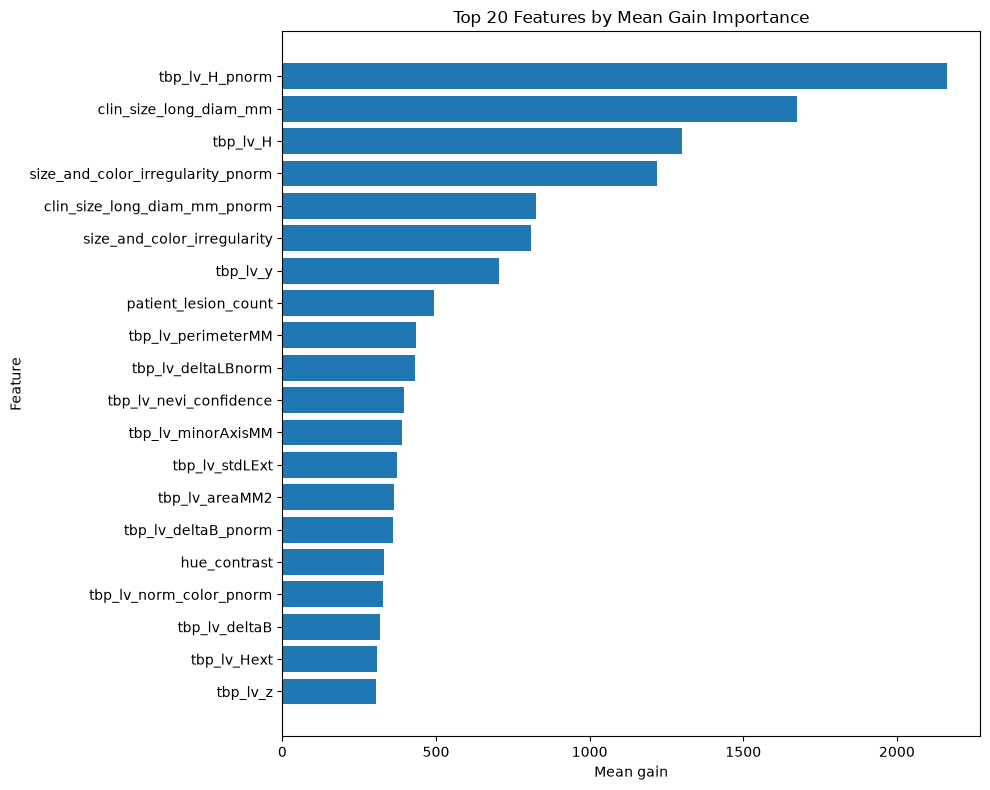

In [115]:
best = res_v3

importance = (
    pd.DataFrame([
        model.booster_.feature_importance(importance_type='gain')
        for model in best['models']
    ], columns=best['models'][0].booster_.feature_name())
    .mean()
    .sort_values(ascending=False)
)

top20 = importance.head(20).sort_values()

plt.figure(figsize=(10, 8))
plt.barh(top20.index, top20.values)
plt.xlabel("Mean gain")
plt.ylabel("Feature")
plt.title("Top 20 Features by Mean Gain Importance")
plt.tight_layout()
plt.show()

## 8. Save out-of-fold predictions
For blending with the CNN later. The predictions are only good for ranking, because the downsampling makes the probabilities too high.

In [119]:
oof_lgbm = train[['isic_id', 'patient_id', 'target', 'fold']].copy()
oof_lgbm['oof'] = best['oof']

oof_lgbm.to_csv(
    '../data/oof_lgbm.csv',
    index=False
)

pd.read_csv('../data/oof_lgbm.csv').head()

,isic_id,patient_id,target,fold,oof
0,ISIC_0015670,IP_1235828,0,1,0.000024
1,ISIC_0015845,IP_8170065,0,4,0.999918
2,ISIC_0015864,IP_6724798,0,4,0.000009
3,ISIC_0015902,IP_4111386,0,1,0.000037
4,ISIC_0024200,IP_8313778,0,1,0.000128
